In [1]:
import os
from pathlib import Path
os.chdir(Path().resolve().parent)

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from data_loader.data_loaders import label_encoding, get_dataloader, get_within_decade_split, get_transfer_split, transform
from models.cnn import PosterCNN

In [2]:
import yaml
with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

In [3]:
df = pd.read_csv(config["data"]["metadata_path"])

label_to_idx, idx_to_label = label_encoding(df)

num_classes = len(label_to_idx)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print(f'Classes: {list(label_to_idx.keys())}')
print(f'Total samples: {len(df)}')

Classes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Total samples: 85555


In [6]:
def load_and_evaluate(exp_name, test_df):
    model = PosterCNN(num_classes=num_classes)
    model.load_state_dict(torch.load(f'checkpoints/{exp_name}_best.pt', weights_only=True, map_location=device))

    model = model.to(device)
    model.eval()

    loader = get_dataloader(test_df, label_to_idx, transform, batch_size=64, shuffle=False, num_workers=0)

    all_predictions = []
    
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            predictions = model(images).argmax(dim=1).cpu()
            all_predictions.append(predictions)
            all_labels.append(labels)

    return torch.cat(all_predictions).numpy(), torch.cat(all_labels).numpy()

In [7]:
experiments = {
    "within_1980s": get_within_decade_split(df, 1980),
    "within_2010s": get_within_decade_split(df, 2010),
    "forward_1980s_1990s": get_transfer_split(df, 1980, 1990),
    "large_gap_1980s_2020s": get_transfer_split(df, 1980, 2020),
    "backward_2010s_1980s": get_transfer_split(df, 2010, 1980),
}

Within 1980s | Train: 15376 | Val: 1922 | Test: 1922
Within 2010s | Train: 14216 | Val: 1778 | Test: 1778
Transfer 1980s -> 1990s | Train: 15376 | Val: 3844 | Test: 22489
Transfer 1980s -> 2020s | Train: 15376 | Val: 3844 | Test: 4390
Transfer 2010s -> 1980s | Train: 14217 | Val: 3555 | Test: 19220


In [8]:
results = {}

for exp_name, (train_df, val_df, test_df) in experiments.items():
    predictions, labels = load_and_evaluate(exp_name, test_df)
    f1 = f1_score(labels, predictions, average="macro")
    results[exp_name] = {'predictions': predictions, 'labels': labels, 'f1': f1}

    print(f'{exp_name}: F1 = {f1:.4f}')

within_1980s: F1 = 0.4006
within_2010s: F1 = 0.4018
forward_1980s_1990s: F1 = 0.0797
large_gap_1980s_2020s: F1 = 0.0750
backward_2010s_1980s: F1 = 0.0754


/tmp/ipykernel_3263776/1785543453.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


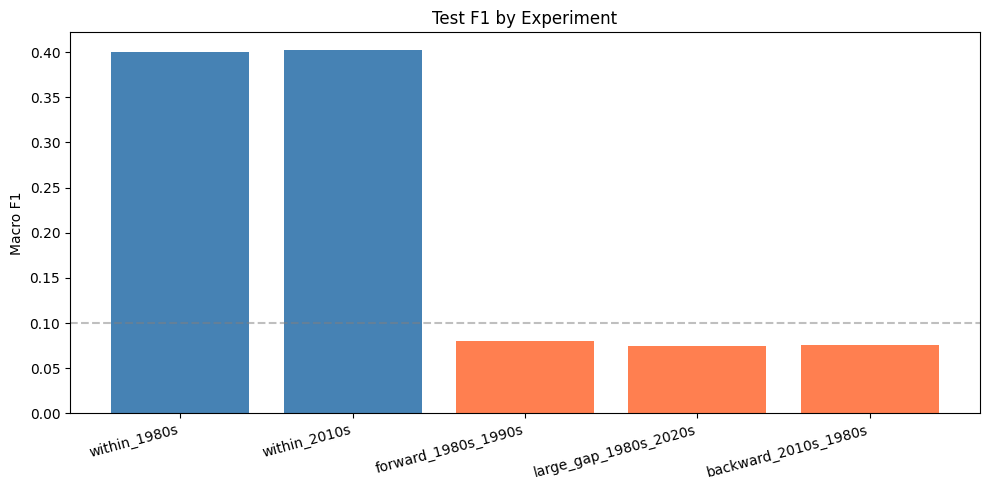

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
f1s = [results[e]['f1'] for e in names]
colors = ['steelblue', 'steelblue', 'coral', 'coral', 'coral']


ax.bar(names, f1s, color=colors)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Near-random threshold')
ax.set_ylabel("Macro F1")
ax.set_title("Test F1 by Experiment")
ax.set_xticklabels(names, rotation=15, ha='right')
plt.tight_layout()
plt.savefig("assets/f1_summary.png", dpi=150)
plt.show()

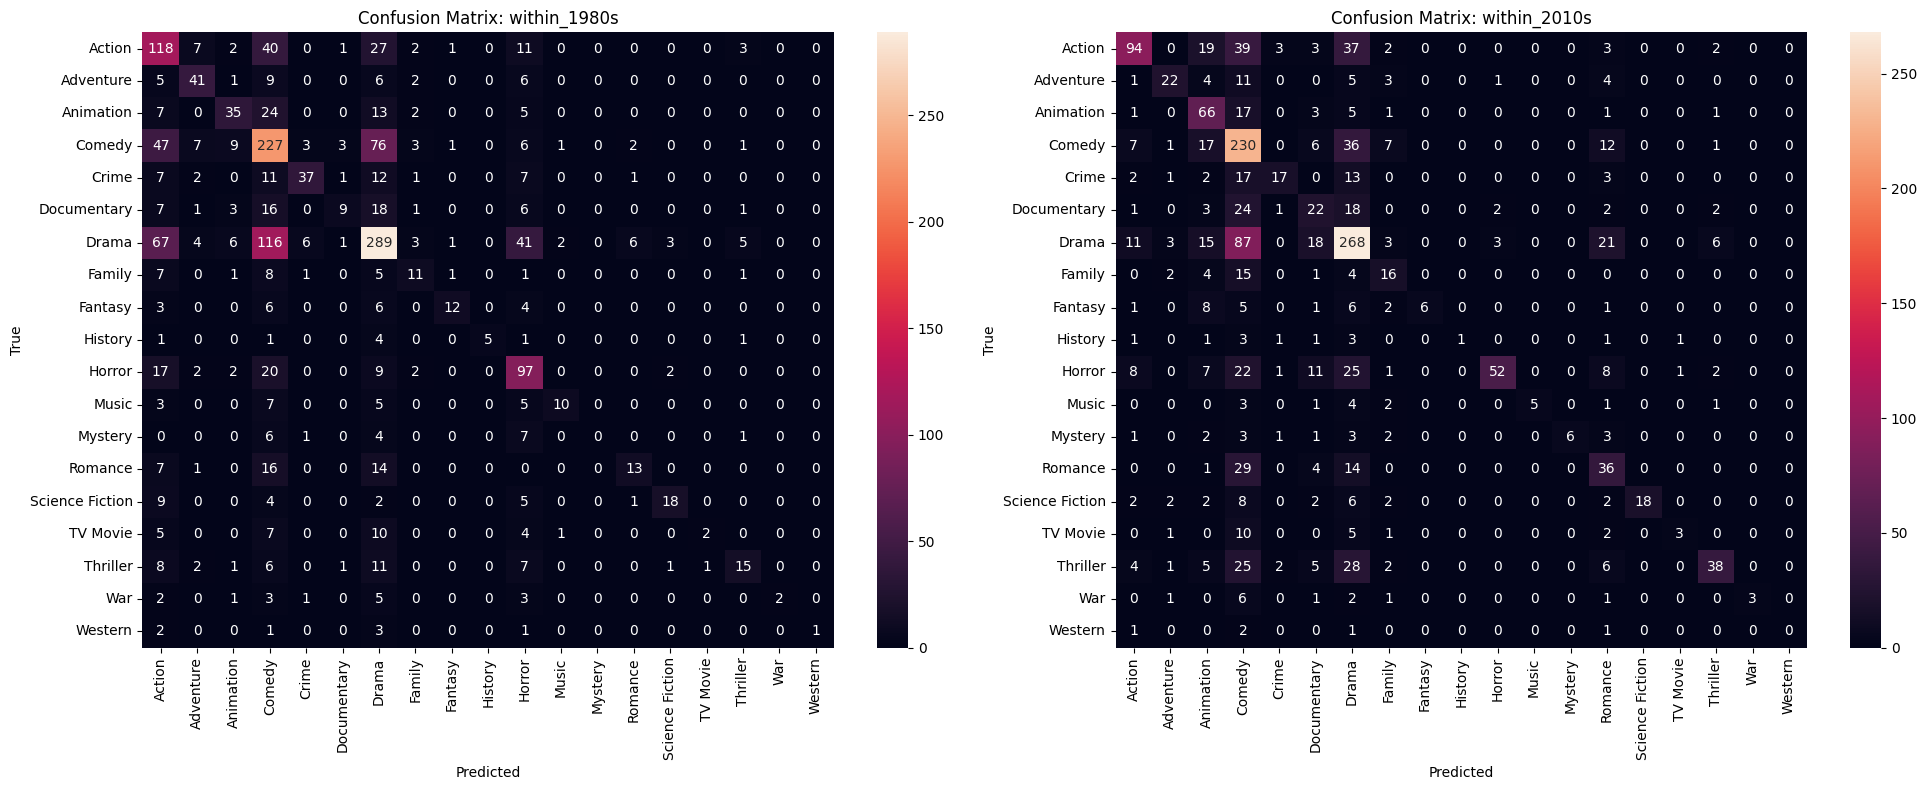

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
genre_names = list(label_to_idx.keys())

for ax, exp_name in zip(axes, ["within_1980s", "within_2010s"]):
    cm = confusion_matrix(results[exp_name]["labels"], results[exp_name]["predictions"])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=genre_names, yticklabels=genre_names)
    ax.set_title(f"Confusion Matrix: {exp_name}")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("assets/confusion_matrices.png", dpi=150)
plt.show()